In [25]:
import torch
from torchinfo import summary
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import _LRScheduler
import torch.utils.data as data
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn import decomposition
from sklearn import manifold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import numpy as np
import copy
import random
import time
from torch.utils.data import Dataset, DataLoader, random_split
import os
import seaborn as sns

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gourangamaitymca/kmc-renal-liver-dataset-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/gourangamaitymca/kmc-renal-liver-dataset-classification


In [27]:
BATCH_SIZE=16
IMG_SIZE=224

In [28]:
from torchvision import datasets, transforms 

In [29]:
train_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_test_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [30]:
train_dataset=datasets.ImageFolder(
    root="/kaggle/input/datasets/gourangamaitymca/kmc-renal-liver-dataset-classification/TCGA-KIDNEY-FINAL/Data/Training",
    transform=train_transform
)

val_dataset=datasets.ImageFolder(
    root="/kaggle/input/datasets/gourangamaitymca/kmc-renal-liver-dataset-classification/TCGA-KIDNEY-FINAL/Data/Validation",
    transform=val_test_transform
)
test_dataset=datasets.ImageFolder(
    root="/kaggle/input/datasets/gourangamaitymca/kmc-renal-liver-dataset-classification/TCGA-KIDNEY-FINAL/Data/Test",
    transform=val_test_transform
)

In [31]:
from torch.utils.data import DataLoader

In [32]:
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)
val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)
test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

In [33]:
import torch
import torch.nn as nn
import torchvision.models as models


class TrueResNet50Fusion_NoAttention(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        resnet = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )

        # Freeze backbone
        for param in resnet.parameters():
            param.requires_grad = False


        # Store all layers exactly like your previous model
        self.layers = nn.ModuleList()

        self.layers.append(resnet.conv1)   # 1
        self.layers.append(resnet.bn1)     # 2
        self.layers.append(resnet.relu)    # 3  <-- extract
        self.layers.append(resnet.maxpool) # 4

        for block in resnet.layer1:        # 5–7
            self.layers.append(block)

        for block in resnet.layer2:        # 8–11  <-- extract at 8
            self.layers.append(block)

        for block in resnet.layer3:        # 12–17
            self.layers.append(block)

        for block in resnet.layer4:        # 18–50 <-- extract at last
            self.layers.append(block)


        # Global pooling
        self.pool = nn.AdaptiveAvgPool2d(1)


        # classifier
        self.classifier = nn.Sequential(

            nn.Linear(64 + 512 + 2048, 1024),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(1024, num_classes)
        )


    def forward(self, x):

        layer_counter = 0

        feat3  = None
        feat8  = None
        feat50 = None


        for layer in self.layers:

            x = layer(x)

            layer_counter += 1


            # 3rd layer output (after relu)
            if layer_counter == 3:

                feat3 = self.pool(x).flatten(1)


            # 8th layer output
            if layer_counter == 8:

                feat8 = self.pool(x).flatten(1)


            # last layer output (50th layer)
            if layer_counter == len(self.layers):

                feat50 = self.pool(x).flatten(1)


        # concatenate features
        fused = torch.cat([feat3, feat8, feat50], dim=1)


        # classification
        out = self.classifier(fused)

        return out

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [35]:
import numpy as np

In [36]:
Targets=np.array(train_dataset.targets)
indices=np.arange(len(Targets))

In [37]:
Targets

array([0, 0, 0, ..., 3, 3, 3])

In [38]:
from sklearn.utils.class_weight import compute_class_weight

In [39]:
classes = np.unique(Targets)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=Targets
)

class_weights = torch.tensor(weights, dtype=torch.float).cuda()


In [40]:
num_classes=len(np.unique(Targets))

In [41]:
model = TrueResNet50Fusion_NoAttention(num_classes).to(device)

In [42]:
from torchinfo import summary

In [43]:
summary(model, input_size=(16 ,3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
TrueResNet50Fusion_NoAttention           [16, 4]                   --
├─ModuleList: 1-5                        --                        (recursive)
│    └─Conv2d: 2-1                       [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                  [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                         [16, 64, 112, 112]        --
├─AdaptiveAvgPool2d: 1-2                 [16, 64, 1, 1]            --
├─ModuleList: 1-5                        --                        (recursive)
│    └─MaxPool2d: 2-4                    [16, 64, 56, 56]          --
│    └─Bottleneck: 2-5                   [16, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [16, 64, 56, 56]          (4,096)
│    │    └─BatchNorm2d: 3-2             [16, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [16, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [16, 64, 5

In [44]:
optimizer = optim.Adam(model.parameters(), lr= 0.0001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)

In [45]:
weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)

In [46]:
criterion=nn.CrossEntropyLoss(weight=weights_tensor)

In [47]:
class_names=['class1','class2','class3','class4']


Epoch [1/100] - Current LRs: [0.0001]

Epoch [1/100]
Train - Loss: 0.8802, Acc: 0.6495, Prec: 0.6483, Recall: 0.6495, F1: 0.6477, specificity: 0.8833,sensitivity: 0.6489
Val   - Loss: 0.5575, Acc: 0.8291, Prec: 0.8377, Recall: 0.8291, F1: 0.8300,specificity: 0.9430,sensitivity: 0.8291
✅ Saved best model (val_loss: 0.5575)



Epoch [2/100] - Current LRs: [0.0001]

Epoch [2/100]
Train - Loss: 0.6555, Acc: 0.7514, Prec: 0.7503, Recall: 0.7514, F1: 0.7500, specificity: 0.9172,sensitivity: 0.7517
Val   - Loss: 0.4727, Acc: 0.8402, Prec: 0.8494, Recall: 0.8402, F1: 0.8399,specificity: 0.9467,sensitivity: 0.8402
✅ Saved best model (val_loss: 0.4727)



Epoch [3/100] - Current LRs: [0.0001]

Epoch [3/100]
Train - Loss: 0.6175, Acc: 0.7578, Prec: 0.7568, Recall: 0.7578, F1: 0.7569, specificity: 0.9193,sensitivity: 0.7575
Val   - Loss: 0.4532, Acc: 0.8497, Prec: 0.8561, Recall: 0.8497, F1: 0.8487,specificity: 0.9499,sensitivity: 0.8497
✅ Saved best model (val_loss: 0.4532)



Epoch [4/100] - Current LRs: [0.0001]

Epoch [4/100]
Train - Loss: 0.5740, Acc: 0.7752, Prec: 0.7745, Recall: 0.7752, F1: 0.7744, specificity: 0.9251,sensitivity: 0.7754
Val   - Loss: 0.4150, Acc: 0.8560, Prec: 0.8628, Recall: 0.8560, F1: 0.8559,specificity: 0.9520,sensitivity: 0.8560
✅ Saved best model (val_loss: 0.4150)



Epoch [5/100] - Current LRs: [0.0001]

Epoch [5/100]
Train - Loss: 0.5448, Acc: 0.7951, Prec: 0.7943, Recall: 0.7951, F1: 0.7942, specificity: 0.9317,sensitivity: 0.7948
Val   - Loss: 0.4203, Acc: 0.8560, Prec: 0.8601, Recall: 0.8560, F1: 0.8554,specificity: 0.9520,sensitivity: 0.8560
⏳ No improvement in val_loss for 1 epoch(s)


...


Epoch [72/100] - Current LRs: [1.0000000000000004e-08]

Epoch [72/100]
Train - Loss: 0.4002, Acc: 0.8473, Prec: 0.8470, Recall: 0.8473, F1: 0.8469, specificity: 0.9491,sensitivity: 0.8476
Val   - Loss: 0.3516, Acc: 0.8861, Prec: 0.8875, Recall: 0.8861, F1: 0.8861,specificity: 0.9620,sensitivity: 0.8861
⏳ No improvement in val_loss for 36 epoch(s)



Epoch [73/100] - Current LRs: [1.0000000000000004e-08]

Epoch [73/100]
Train - Loss: 0.3894, Acc: 0.8575, Prec: 0.8573, Recall: 0.8575, F1: 0.8573, specificity: 0.9525,sensitivity: 0.8575
Val   - Loss: 0.3535, Acc: 0.8782, Prec: 0.8824, Recall: 0.8782, F1: 0.8783,specificity: 0.9594,sensitivity: 0.8782
⏳ No improvement in val_loss for 37 epoch(s)



Epoch [74/100] - Current LRs: [1.0000000000000004e-08]

Epoch [74/100]
Train - Loss: 0.4004, Acc: 0.8531, Prec: 0.8531, Recall: 0.8531, F1: 0.8528, specificity: 0.9511,sensitivity: 0.8535
Val   - Loss: 0.3495, Acc: 0.8766, Prec: 0.8787, Recall: 0.8766, F1: 0.8769,specificity: 0.9589,sensitivity: 0.8766
⏳ No improvement in val_loss for 38 epoch(s)



Epoch [75/100] - Current LRs: [1.0000000000000004e-08]

Epoch [75/100]
Train - Loss: 0.3859, Acc: 0.8558, Prec: 0.8555, Recall: 0.8558, F1: 0.8553, specificity: 0.9520,sensitivity: 0.8556
Val   - Loss: 0.3525, Acc: 0.8829, Prec: 0.8852, Recall: 0.8829, F1: 0.8833,specificity: 0.9610,sensitivity: 0.8829
⏳ No improvement in val_loss for 39 epoch(s)



Epoch [76/100] - Current LRs: [1.0000000000000004e-08]

Epoch [76/100]
Train - Loss: 0.3997, Acc: 0.8437, Prec: 0.8431, Recall: 0.8437, F1: 0.8432, specificity: 0.9479,sensitivity: 0.8436
Val   - Loss: 0.3435, Acc: 0.8845, Prec: 0.8865, Recall: 0.8845, F1: 0.8847,specificity: 0.9615,sensitivity: 0.8845
⏳ No improvement in val_loss for 40 epoch(s)
🛑 Early stopping triggered after 40 epochs without improvement.


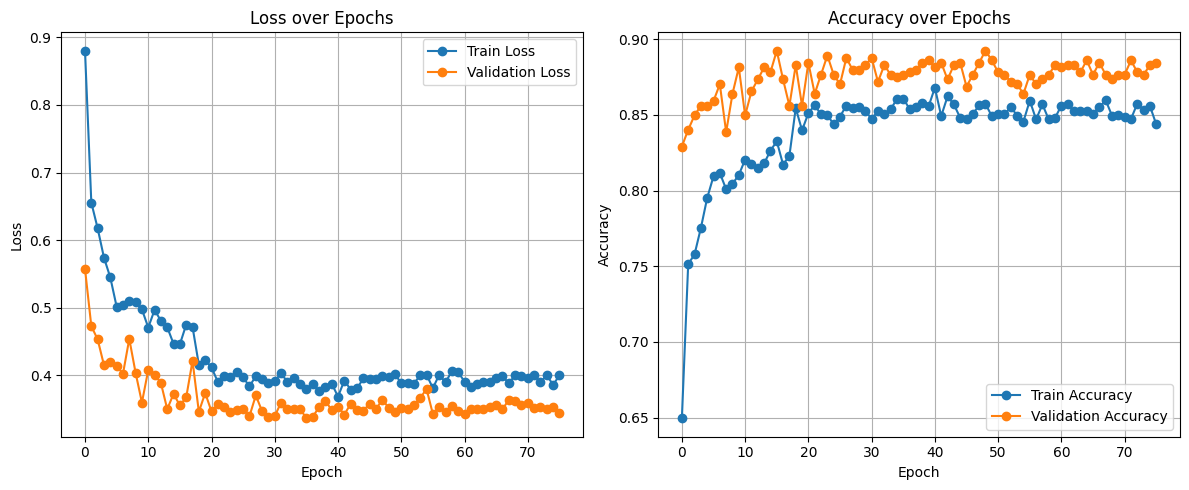

📥 Loaded the best saved model for final testing.

🔍 Evaluating on Test Set:


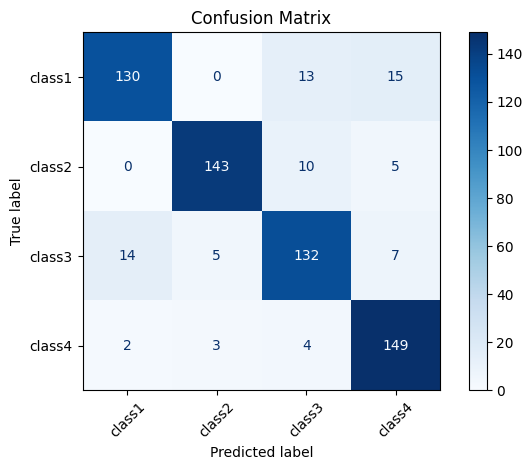


🔍 Classification Report
              precision    recall  f1-score   support

      class1       0.89      0.82      0.86       158
      class2       0.95      0.91      0.93       158
      class3       0.83      0.84      0.83       158
      class4       0.85      0.94      0.89       158

    accuracy                           0.88       632
   macro avg       0.88      0.88      0.88       632
weighted avg       0.88      0.88      0.88       632

Test - Loss: 0.3366, Acc: 0.8766, Prec: 0.8786, Recall: 0.8766, F1: 0.8765
✅ Correct Predictions: 554/632 (87.66%)


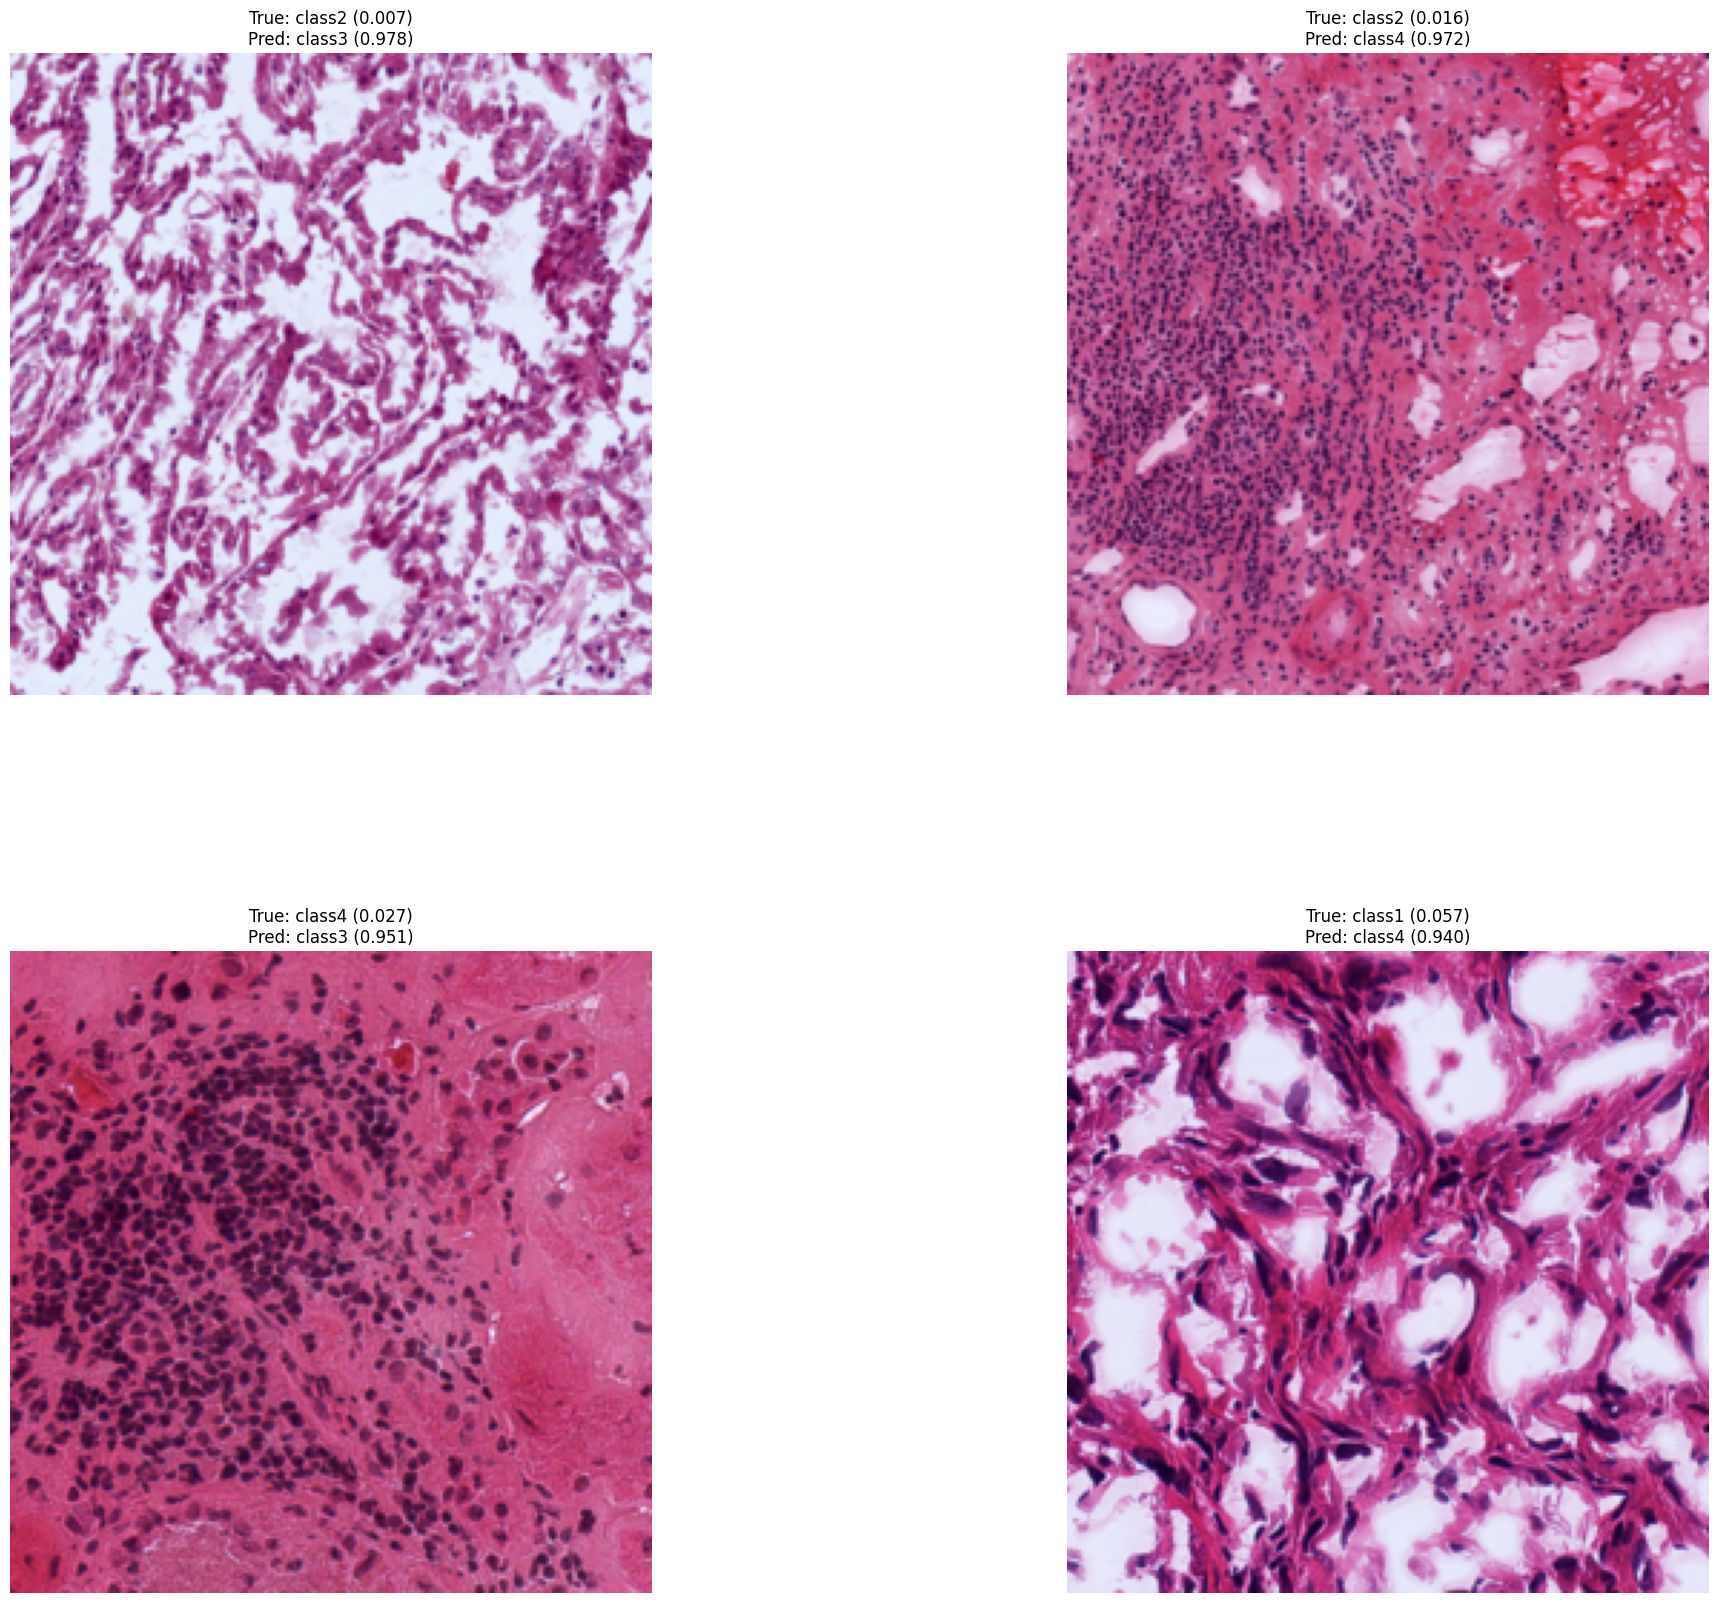

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize


# -------------------- Metric Computation --------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(labels, preds):
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted', zero_division=0)
    rec = recall_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)
     # Sensitivity & Specificity (macro-averaged)
    cm = confusion_matrix(labels, preds)
    sensitivity_per_class = []
    specificity_per_class = []
    for i in range(cm.shape[0]):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FP + FN)

        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

        sensitivity_per_class.append(sensitivity)
        specificity_per_class.append(specificity)

    sensitivity_macro = np.mean(sensitivity_per_class)
    specificity_macro = np.mean(specificity_per_class)

    return acc, prec, rec, f1,sensitivity_macro, specificity_macro

# -------------------- Normalize Function --------------------
def normalize_image(img_tensor):
    img = img_tensor.clone()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

# -------------------- Training Step --------------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    all_preds, all_labels = [], []
    running_loss = 0.0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1,sensitivity_macro, specificity_macro = compute_metrics(all_labels, all_preds)
    return epoch_loss, acc, prec, rec, f1,sensitivity_macro, specificity_macro

# -------------------- Validation Step --------------------
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    all_preds, all_labels = [], []
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1,sensitivity_macro, specificity_macro = compute_metrics(all_labels, all_preds)
    return epoch_loss, acc, prec, rec, f1,sensitivity_macro, specificity_macro

# -------------------- Test Step --------------------
# -------------------- Modified Test Step (Removed AUC-ROC Curve) --------------------
def test_model(model, loader, criterion, device, class_names=None):
    model.eval()
    all_preds, all_labels = [], []
    all_images, all_probs = [], []
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_images.extend(images.cpu())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1,sensitivity_macro, specificity_macro = compute_metrics(all_labels, all_preds)

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print("\n🔍 Classification Report")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    return avg_loss, acc, prec, rec, f1, all_labels, all_preds, all_images, torch.tensor(np.vstack(all_probs))

   

    
# -------------------- Plot Incorrect Predictions --------------------
def plot_most_incorrect(incorrect, classes, n_images, normalize=True):
    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(25, 20))
    for i in range(min(rows * cols, len(incorrect))):
        ax = fig.add_subplot(rows, cols, i+1)
        image, true_label, probs = incorrect[i]
        image = image.permute(1, 2, 0)
        true_prob = probs[true_label]
        incorrect_prob, incorrect_label = torch.max(probs, dim=0)
        true_class = classes[true_label]
        incorrect_class = classes[incorrect_label]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.numpy())
        ax.set_title(f'True: {true_class} ({true_prob:.3f})\nPred: {incorrect_class} ({incorrect_prob:.3f})')
        ax.axis('off')

    fig.subplots_adjust(hspace=0.4)
    plt.show()

def run_training(model, train_loader, val_loader, test_loader, optimizer, criterion, device, class_names=None, num_epochs=400,patience=20 ):
    best_val_loss = float('inf')
    
    # Lists to store loss and accuracy for each epoch
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [],[]
    epochs_without_improvement = 0 

    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1,train_sensitivity_macro, train_specificity_macro = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_prec, val_rec, val_f1,val_sensitivity_macro, val_specificity_macro = validate_one_epoch(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        # 🔹 Print current learning rate(s)
        current_lrs = [param_group['lr'] for param_group in optimizer.param_groups]
        print(f"\nEpoch [{epoch+1}/{num_epochs}] - Current LRs: {current_lrs}")

        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Recall: {train_rec:.4f}, F1: {train_f1:.4f}, specificity: {train_specificity_macro:.4f},sensitivity: {train_sensitivity_macro:.4f}")
        print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Prec: {val_prec:.4f}, Recall: {val_rec:.4f}, F1: {val_f1:.4f},specificity: {val_specificity_macro:.4f},sensitivity: {val_sensitivity_macro:.4f}")
        scheduler.step(val_loss)

        # Save best model by validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"✅ Saved best model (val_loss: {val_loss:.4f})")
        else:
            epochs_without_improvement += 1
            print(f"⏳ No improvement in val_loss for {epochs_without_improvement} epoch(s)")

            if epochs_without_improvement >= patience:
                print(f"🛑 Early stopping triggered after {patience} epochs without improvement.")
                break


    # 📊 Plotting Loss and Accuracy Curves
    plt.figure(figsize=(12, 5))

    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Validation Loss', marker='o')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy', marker='o')
    plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Load the best model before testing
    model.load_state_dict(torch.load('best_model.pth'))
    print("📥 Loaded the best saved model for final testing.")

    print("\n🔍 Evaluating on Test Set:")
    test_loss, test_acc, test_prec, test_rec, test_f1, all_labels, all_preds, all_images, all_probs = test_model(
        model, test_loader, criterion, device, class_names
    )

    print(f"Test - Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Recall: {test_rec:.4f}, F1: {test_f1:.4f}")
    
    corrects = torch.eq(torch.tensor(all_labels), torch.tensor(all_preds))
    num_correct = corrects.sum().item()
    total = len(corrects)
    print(f"✅ Correct Predictions: {num_correct}/{total} ({100 * num_correct / total:.2f}%)")

    incorrect_examples = []
    for image, label, prob, correct in zip(all_images, all_labels, all_probs, corrects):
        if not correct:
            incorrect_examples.append((image, label, prob))

    incorrect_examples.sort(reverse=True, key=lambda x: torch.max(x[2]).item())
    N_IMAGES = 6
    plot_most_incorrect(incorrect_examples, class_names, N_IMAGES)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    class_names=['class1','class2','class3','class4'],
    num_epochs=100,
    patience=40
)